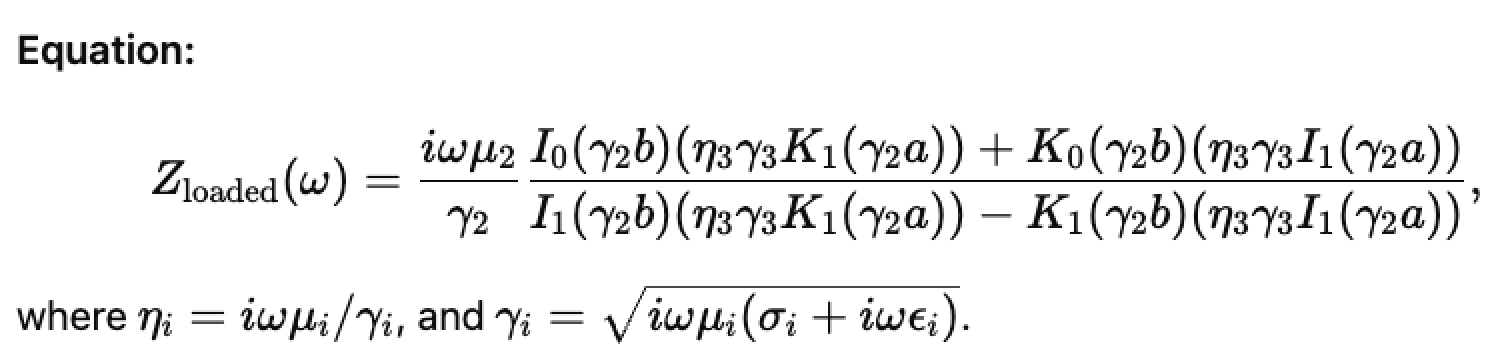

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv, i0, i1, k0, k1

from scipy.constants import mu_0, epsilon_0

In [2]:
def admittivity(omega, sigma, eps=0.0):
    return sigma + 1j*omega*eps

def gamma(omega, mu, sigma, eps=0.0):
    # γ = sqrt(i ω μ (σ + i ω ε))
    return np.sqrt(1j*omega*mu*admittivity(omega, sigma, eps))

def eta_tm(omega, mu, sigma, eps=0.0):
    # η = i ω μ / γ   (TM impedance used in the derivations)
    g = gamma(omega, mu, sigma, eps)
    return 1j*omega*mu/g


In [84]:

# -------- Parameters (EDIT) --------
mu_r = 100.0
mu = mu_0*mu_r
sigma = 5e6           # S/m
eps = 0.0             # F/m (steel: displacement negligible here)
b = 0.05              # outer radius [m]
t = 0.01              # wall thickness [m]
a = b - t             # inner radius [m]; set a=0 for solid
f = np.logspace(-2, 4, 500)   # Hz
w = 2*np.pi*f

# define the different media
mu1 = mu_0
sigma1 = 1e-6

mu2 = mu
sigma2 = sigma

eps1=eps2=0

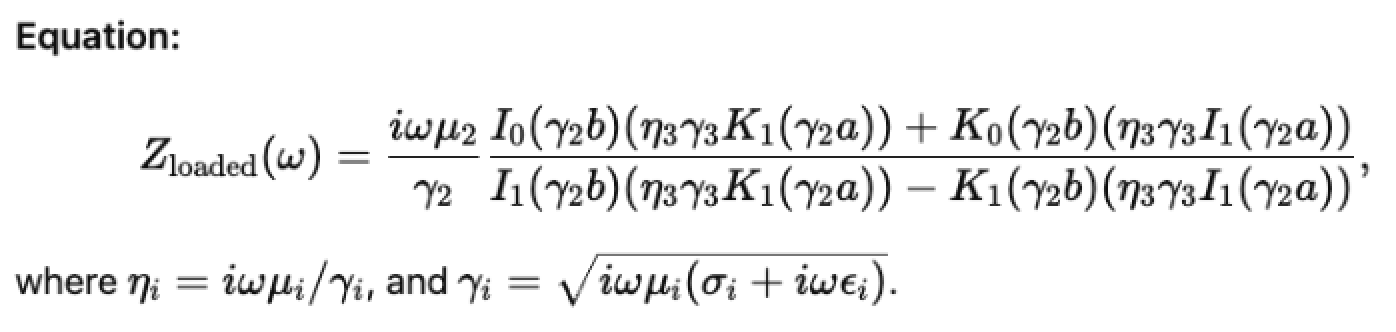

In [85]:
# --- Cylindrical surface impedance (3-region symmetric medium)
def impedance_cyl_symmetric(omega, a, b, mu1, sigma1, mu2, sigma2, eps=0):
    """Full 3-region impedance, loaded both sides"""
    g1 = gamma(omega, mu1, sigma1)
    g2 = gamma(omega, mu2, sigma2)
    eta1 = 1j*omega*mu1/g1

    I0b, I1b = iv(0, g2*b), iv(1, g2*b)
    K0b, K1b = kv(0, g2*b), kv(1, g2*b)
    I1a, K1a = iv(1, g2*a), kv(1, g2*a)

    num = I0b*(eta1*g1*K1a) + K0b*(eta1*g1*I1a)
    den = I1b*(eta1*g1*K1a) - K1b*(eta1*g1*I1a)
    return (1j*omega*mu2/g2)*(num/den)

In [86]:
def impedance_sheet(omega, t, mu2, sigma2, eps2=0.0):
    g2 = gamma(omega, mu2, sigma2, eps2)
    eta2 = 1j*omega*mu2/g2
    return eta2/np.tanh(g2*t)   # = eta2 * coth(g2 t)


In [87]:
def impedance_solid_cyl(omega, b, mu, sigma, eps=0.0):
    g = gamma(omega, mu, sigma, eps)
    I0b, I1b = iv(0, g*b), iv(1, g*b)
    eta = (1j*omega*mu/g)
    return  eta * (I0b/I1b)

In [88]:
def impedance_open_cyl(omega, a=a, b=b, mu=mu, sigma=sigma, eps=0):
    """
    Hollow cylinder with 'open' bore at r=a (Hφ(a)≈0):
    Z = (iωμ/γ) * [I0(γ b) + α K0(γ b)] / [α K1(γ b) - I1(γ b)],
    where α = I1(γ a) / K1(γ a).
    """
    g = gamma(omega, mu, sigma, eps)
    I0b, I1b = iv(0, g*b), iv(1, g*b)
    K0b, K1b = kv(0, g*b), kv(1, g*b)
    I1a, K1a = iv(1, g*a), kv(1, g*a)
    num = I0b * K1a + K0b*I1a
    den = I1b * K1a - K1b*I1a
    return (1j*omega*mu/g) * (num/den)

In [89]:
Z_sheet = impedance_sheet(w, b-a, mu2, sigma2)
Z_casing = impedance_cyl_symmetric(w, a, b, mu1, sigma1, mu2, sigma2)
Z_open = impedance_open_cyl(w, a, b, mu2, sigma2)
Z_solid = impedance_solid_cyl(w, b, mu2, sigma2)

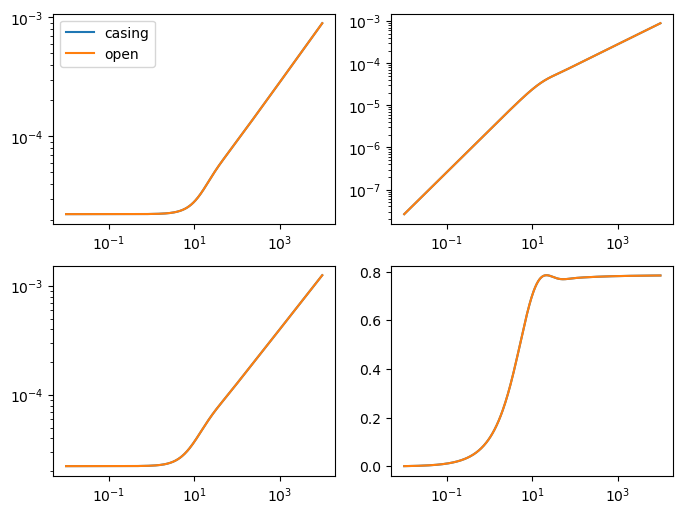

In [94]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

for ai, comp in zip(ax[0, :], ["real", "imag"]): 
    # ai.loglog(f, getattr(Z_sheet, comp), label="sheet")
    ai.loglog(f, getattr(Z_casing, comp), label="casing")
    ai.loglog(f, getattr(Z_open, comp), label="open")

# ax[1, 0].loglog(f, np.abs(Z_sheet))
ax[1, 0].loglog(f, np.abs(Z_casing))
ax[1, 0].loglog(f, np.abs(Z_open))

# ax[1, 1].semilogx(f, np.atan2(Z_sheet.imag, Z_sheet.real))
ax[1, 1].semilogx(f, np.atan2(Z_casing.imag, Z_casing.real))
ax[1, 1].semilogx(f, np.atan2(Z_open.imag, Z_open.real))

ax[0, 0].legend()

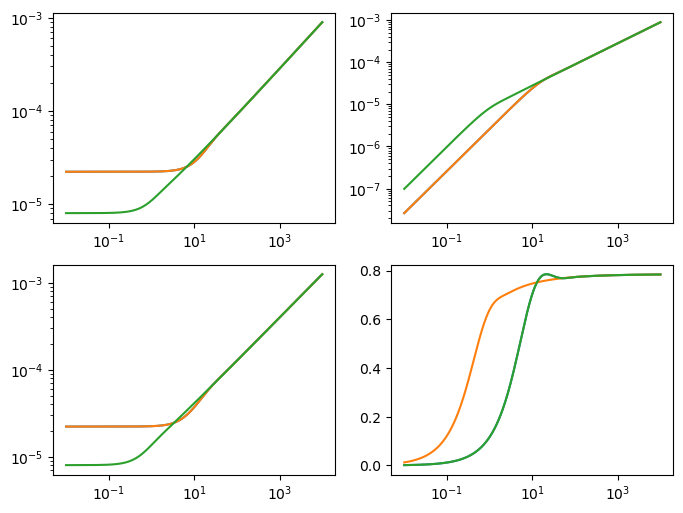

In [91]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

for ai, comp in zip(ax[0, :], ["real", "imag"]): 
    # ai.loglog(f, getattr(Z_sheet, comp))
    ai.loglog(f, getattr(Z_casing, comp))
    ai.loglog(f, getattr(Z_open, comp))
    ai.loglog(f, getattr(Z_solid, comp))

# ax[1, 0].loglog(f, np.abs(Z_sheet))
ax[1, 0].loglog(f, np.abs(Z_casing))
ax[1, 0].loglog(f, np.abs(Z_open))
ax[1, 0].loglog(f, np.abs(Z_solid))

# ax[1, 1].semilogx(f, np.atan2(Z_sheet.imag, Z_sheet.real))
ax[1, 1].semilogx(f, np.atan2(Z_casing.imag, Z_casing.real))
ax[1, 1].semilogx(f, np.atan2(Z_solid.imag, Z_solid.real))

ax[1, 1].semilogx(f, np.atan2(Z_open.imag, Z_open.real))

